OverkillModel trained for 5000 epochs and got 0.085 training loss. If you now evaluate it on 20 held-out samples it has never seen, what do you expect the test loss to be — lower than 0.085, similar, or significantly higher? Write your reasoning before Part 1.
#Ans:
its gonna be ofcourse higher than 0.085 but we dont know how much higher , lets find out

In [1]:
import torch
import torch.nn as nn
torch.manual_seed(42)

X = torch.randn(100,2)
distance = torch.sqrt(X[:, 0:1]**2 + X[: , 1:2]**2)
true_logits = - (distance - 1)
true_prob = torch.sigmoid(true_logits)
y = torch.bernoulli(true_prob)

X_train , X_test = X[:80], X[80:]
y_train , y_test = y[:80], y[80:]

print("Training samples:", X_train.shape[0])
print("Test samples:" , X_test.shape[0])

 # TODO: why take the first 80 and last 20?
 #answer :becasue we have total of 100 numbers and we are taking
 #80 percent of it to train and the rest of 20 percent to test of the whole data

# TODO: is this a good way to split? think about whether the data ordering matters
#


Training samples: 80
Test samples: 20


In [5]:
loss_fn = nn.BCEWithLogitsLoss()

class OneLayerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 8)
        self.output = nn.Linear(8, 1)
    def forward(self, x):
        x = torch.relu(self.hidden(x))
        return self.output(x)

class OverkillModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.h1 = nn.Linear(2, 64)
        self.h2 = nn.Linear(64, 64)
        self.h3 = nn.Linear(64, 64)
        self.h4 = nn.Linear(64, 64)
        self.output = nn.Linear(64, 1)
    def forward(self, x):
        x = torch.relu(self.h1(x))
        x = torch.relu(self.h2(x))
        x = torch.relu(self.h3(x))
        x = torch.relu(self.h4(x))
        return self.output(x)

def train_and_evaluate(model, epochs=2000, lr=0.1):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        # --- TRAINING STEP (only on X_train) ---
        model.train()                          # TODO: what does model.train() do?
        y_pred_train = model(X_train)
        loss_train = loss_fn(y_pred_train, y_train)
        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()
        train_losses.append(loss_train.item())

        # --- EVALUATION STEP (only on X_test) ---
        model.eval()                           # TODO: what does model.eval() do?
        with torch.no_grad():                  # TODO: why no_grad() here specifically?
            loss_test = loss_fn(y_pred_test, y_test)
        test_losses.append(loss_test.item())

    return train_losses, test_losses

one_train, one_test = train_and_evaluate(OneLayerModel(), epochs=2000)
overkill_train, overkill_test = train_and_evaluate(OverkillModel(), epochs=2000)

print("=== OneLayerModel ===")
print(f"Final train loss: {one_train[-1]:.4f}")
print(f"Final test loss:  {one_test[-1]:.4f}")
print(f"Gap:              {one_test[-1] - one_train[-1]:.4f}")

print("\n=== OverkillModel ===")
print(f"Final train loss: {overkill_train[-1]:.4f}")
print(f"Final test loss:  {overkill_test[-1]:.4f}")
print(f"Gap:              {overkill_test[-1] - overkill_train[-1]:.4f}")

=== OneLayerModel ===
Final train loss: 0.5972
Final test loss:  0.7501
Gap:              0.1530

=== OverkillModel ===
Final train loss: 0.4565
Final test loss:  0.9498
Gap:              0.4933


 << TODO: what does model.train() do?
 *i think it trains the model


 << TODO: what does model.eval() do?

*the model.eval evaluate the models like in train and test losses and accuracy*

TODO: why no_grad() here specifically?

*no use of grad_zero specifically because we dont need to now write it for each variable specifically , aanother perk of using optimizer in nn module , optimzer no grad automatically does it.


**Checkpoint:** OverkillModel should show a large gap between train and test loss. OneLayerModel's gap should be much smaller. If OverkillModel's test loss is *higher* than OneLayerModel's test loss despite lower training loss — that's overfitting confirmed in numbers.

=== OneLayerModel ===
Final train loss: 0.5972
Final test loss:  0.7501
Gap:              0.1530

=== OverkillModel ===
Final train loss: 0.4565
Final test loss:  0.9498
Gap:              0.4933

*it is confirmed byt he number yes*





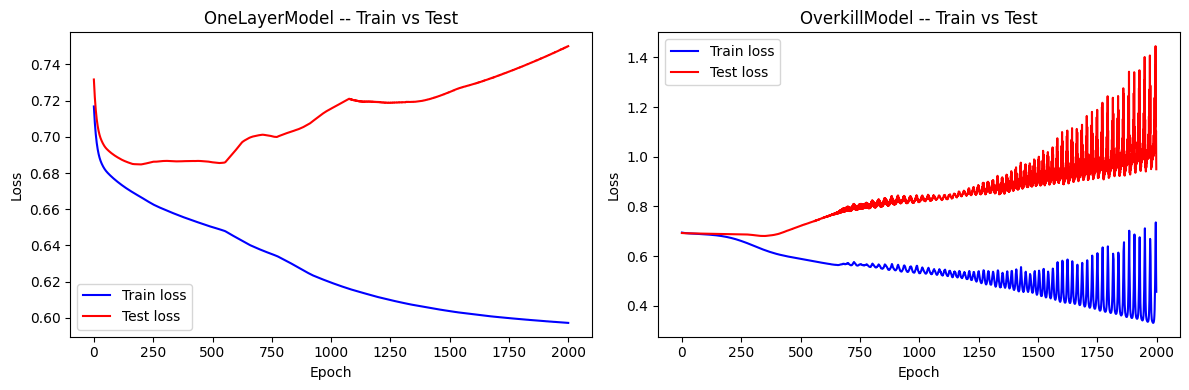

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# OneLayerModel curves
axes[0].plot(one_train, label='Train loss', color='blue')
axes[0].plot(one_test, label='Test loss', color='red')
axes[0].set_title("OneLayerModel -- Train vs Test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# OverkillModel curves
axes[1].plot(overkill_train, label='Train loss', color='blue')
axes[1].plot(overkill_test, label='Test loss', color='red')
axes[1].set_title("OverkillModel -- Train vs Test")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

**Answer these after looking at the plots:**
1. For OneLayerModel: are the blue and red curves close together or far apart?
2. For OverkillModel: at what epoch do the blue and red curves start to diverge?
3. The point where they diverge is where overfitting begins. Where would you have stopped OverkillModel's training to get the best *test* performance?

*1) for one layer model , they start at the same place around the 0.73 and then moving down and then after 50 epochs start to drift really far apart , train loss goes down and test loss go up*

*2) for overkill around 300 epooch they start to diverge*

*3) at about 250 epoch thats it , after that they really start to diverge*

**Predict-before-run, Q2:** If you kept training OverkillModel for 10,000 epochs instead of 2000, what happens to the gap between train and test loss — does it grow, shrink, or stay the same?

*even if i kept training it till 10,000 epochs it will just keep having grater gap between train loss and test loss , and it will go towards greater overfitting case  making it more difficult to fix*

In [8]:
best_epoch = overkill_test.index(min(overkill_test))
best_test_loss = overkill_test[best_epoch]

print(f"Best test loss: {best_test_loss:.4f} at epoch {best_epoch}")
print(f"Final test loss: {overkill_test[-1]:.4f} at epoch 2000")
print(f"Difference: {overkill_test[-1] - best_test_loss:.4f}")

# Best test loss: 0.6811 at epoch 342
# Final test loss: 0.9498 at epoch 2000
# Difference: 0.2686

Best test loss: 0.6811 at epoch 342
Final test loss: 0.9498 at epoch 2000
Difference: 0.2686


In [9]:
torch.manual_seed(42)
X = torch.randn(100, 2)
distance = torch.sqrt(X[:, 0:1]**2 + X[:, 1:2]**2)
true_logit = -(distance - 1)
true_prob = torch.sigmoid(true_logit)
y = torch.bernoulli(true_prob)

# --- Version A (what you did in Part 1) ---
X_train_A, X_test_A = X[:80], X[80:]

# --- Version B: compute mean on ALL data, then split ---
X_mean = X.mean(dim=0)            # computed on 100 samples including test
X_normalized = X - X_mean         # normalized using ALL data
X_train_B, X_test_B = X_normalized[:80], X_normalized[80:]

Answer these without running anything first:

1. In Version B, the test set normalization used information from the test samples (`X_mean` was computed on all 100). Why is that a problem?
2. What is the correct order of operations: normalize then split, or split then normalize?
3. In a real medical dataset where you're normalizing blood pressure readings — what happens to your test results if you accidentally leak test statistics into your normalization step?


*1<< becasue they did normalization before the splitting , that give the info of the test data to the into the train data , so the testing results would not be the same, oh ohh ohhh , got it got it*

*2<< i think correct order would be split first then normalize the data separately so the data desont leak from train to test or vice versa*

*3<< i think that would cause the reading to be not accurate , you can explain to me the rest*







## Journal

1. Write all four numbers side by side: OneLayerModel train loss, OneLayerModel test loss, OverkillModel train loss, OverkillModel test loss. Which model actually wins when measured honestly?
2. In your own words: what is the difference between training loss and test loss, and why does only one of them tell you something real?
3. What is data leakage and why is it worse than overfitting? (Hint: overfitting you can *see*. Leakage you often can't.)
4. Boss Round in your own words: explain the Version B bug to someone who just finished Day 36.
5. Post-seed check: does anything from today connect to your CVD research project? You have a dataset there — have you thought about how it was split, or whether the split happened correctly?


##1##
=== OneLayerModel ===
Final train loss: 0.5972
Final test loss:  0.7501
Gap:              0.1530

=== OverkillModel ===
Final train loss: 0.4565
Final test loss:  0.9498
Gap:              0.4933


##2##

the training loss in my own words will be the loss you get after training a model on some data and suring training if it gets trains on the data or not and how accurately it knows the train data m not on the other hand the test loss is the loss you get after the training is done and you test the model on test data that was separated from the complete data before training model and model have never seen this data before., so we ca accurately know how much model is actually trained or did it memorize just the training data and fails on any other unseen data.

##3##

overfitting you can *see*. Leakage you often can't., yeah maybe that is the reason it is more of a hidden enemy that overfitting.

##4##

Post-seed check: does anything from today connect to your CVD research project? You have a dataset there — have you thought about how it was split, or whether the split happened correctly?
<< yeah ofcourse  , it will help surely in that sense like if i see the overfitting or run into any error i would be prepared and would be able to deal with it.










